Import Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


 Here imports all required PyTorch, torchvision, and Matplotlib libraries needed for building, training, and visualizing a deep feedforward neural network.

Load & Preprocess Fashion MNIST Data

In [13]:
# Transform: convert image to tensor & normalize
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load dataset
train_dataset = datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transform
)

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))


Training samples: 60000
Testing samples: 10000


Fashion MNIST images are converted into tensors and normalized to improve training stability.DataLoader is used to load data in batches and shuffle training samples for better learning.

Define Deep Feedforward Neural Network

In [14]:
class DeepFFNN(nn.Module):
    def __init__(self):
        super(DeepFFNN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),

            nn.Linear(512, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 10)  # Output layer
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten image
        return self.model(x)


model = DeepFFNN()
print(model)


DeepFFNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=10, bias=True)
  )
)


A deep feedforward neural network with three hidden layers is defined.
ReLU activation introduces non-linearity, and the linear output layer produces logits for multi-class classification.

Initialize Model, Loss, Optimizer

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DeepFFNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Loss and optimizer initialized")


Loss and optimizer initialized


The model is moved to the available device. Cross-entropy loss is used for multi-class classification, and Adam optimizer enables efficient gradient-based learning.

Train the Network

In [6]:
epochs = 10
train_losses = []
train_accuracies = []

for epoch in range(epochs):
    model.train()
    correct = 0
    total = 0
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    train_losses.append(running_loss)
    train_accuracies.append(accuracy)

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss:.4f}, Accuracy: {accuracy:.2f}%")


Epoch [1/10], Loss: 471.5790, Accuracy: 81.47%
Epoch [2/10], Loss: 349.0829, Accuracy: 86.20%
Epoch [3/10], Loss: 312.8562, Accuracy: 87.69%
Epoch [4/10], Loss: 290.6079, Accuracy: 88.44%
Epoch [5/10], Loss: 267.3895, Accuracy: 89.44%
Epoch [6/10], Loss: 255.8762, Accuracy: 89.83%
Epoch [7/10], Loss: 239.1182, Accuracy: 90.41%
Epoch [8/10], Loss: 228.6464, Accuracy: 90.86%
Epoch [9/10], Loss: 216.3083, Accuracy: 91.38%
Epoch [10/10], Loss: 206.7956, Accuracy: 91.69%


During training, the model performs forward propagation to generate predictions and backward propagation to update weights. Training loss decreases and accuracy increases across epochs, indicating effective learning.

Evaluate on Test Data

In [7]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total
print(f"Test Accuracy: {test_accuracy:.2f}%")


Test Accuracy: 88.07%


The trained model is evaluated on unseen test data without gradient computation.
Test accuracy measures the model’s generalization ability.

Plot Training Loss & Accuracy

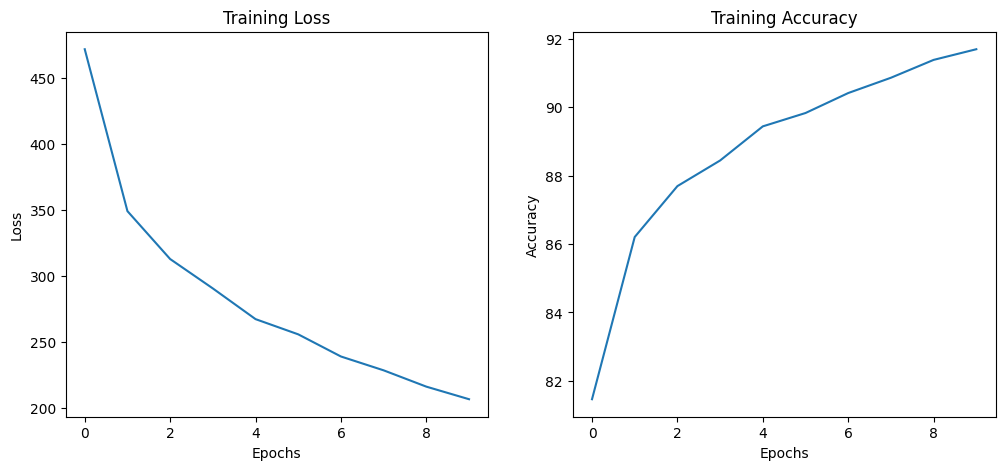

In [8]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(train_accuracies)
plt.title("Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.show()


The loss graph shows a decreasing trend, while the accuracy graph shows an increasing trend.These plots confirm proper convergence of the neural network.

**`ADVANCED TASK 1`**

**`Helper Function to Build Models of Different Depths`**

In [23]:
import time

class VariableDepthNN(nn.Module):
    def __init__(self, hidden_layers):
        super().__init__()
        layers = []
        input_size = 28 * 28

        for neurons in hidden_layers:
            layers.append(nn.Linear(input_size, neurons))
            layers.append(nn.ReLU())
            input_size = neurons

        layers.append(nn.Linear(input_size, 10))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.model(x)


**`Train & Evaluate Function`**

In [24]:
def train_and_evaluate(model, train_loader, test_loader, epochs=3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

    train_time = time.time() - start_time

    # Test accuracy
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return running_loss, accuracy, train_time


**`Run Depth Experiments`**

In [25]:
depth_configs = {
    "1 Hidden Layer": [128],
    "3 Hidden Layers": [512, 256, 128],
    "5 Hidden Layers": [512, 512, 256, 128, 64]
}

print("ADVANCED TASK 1: Depth & Width Experiment\n")

for name, layers in depth_configs.items():
    model = VariableDepthNN(layers)
    loss, acc, t = train_and_evaluate(model, train_loader, test_loader)

    print(f"{name}")
    print(f"  Final Training Loss : {loss:.2f}")
    print(f"  Test Accuracy       : {acc:.2f}%")
    print(f"  Training Time       : {t:.2f} seconds\n")


ADVANCED TASK 1: Depth & Width Experiment

1 Hidden Layer
  Final Training Loss : 319.67
  Test Accuracy       : 85.72%
  Training Time       : 44.48 seconds

3 Hidden Layers
  Final Training Loss : 317.81
  Test Accuracy       : 86.19%
  Training Time       : 63.26 seconds

5 Hidden Layers
  Final Training Loss : 331.09
  Test Accuracy       : 86.55%
  Training Time       : 78.86 seconds



Increasing the number of hidden layers improves feature learning and accuracy. However, deeper networks increase training time and may lead to overfitting.

**`ADVANCED TASK 2`**






**`Model with Variable Activation`**

In [27]:
class ActivationNN(nn.Module):
    def __init__(self, activation):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 256),
            activation,
            nn.Linear(256, 128),
            activation,
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.model(x)


**`Run Activation Experiments`**

In [28]:
activations = {
    "ReLU": nn.ReLU(),
    "Sigmoid": nn.Sigmoid(),
    "Tanh": nn.Tanh(),
    "Leaky ReLU": nn.LeakyReLU(0.01)
}

print("\nADVANCED TASK 2: Activation Function Study\n")

for name, act in activations.items():
    model = ActivationNN(act)
    loss, acc, t = train_and_evaluate(model, train_loader, test_loader)

    print(f"{name}")
    print(f"  Final Training Loss : {loss:.2f}")
    print(f"  Test Accuracy       : {acc:.2f}%")
    print(f"  Training Time       : {t:.2f} seconds\n")



ADVANCED TASK 2: Activation Function Study

ReLU
  Final Training Loss : 312.51
  Test Accuracy       : 87.17%
  Training Time       : 49.22 seconds

Sigmoid
  Final Training Loss : 326.84
  Test Accuracy       : 86.67%
  Training Time       : 48.18 seconds

Tanh
  Final Training Loss : 320.42
  Test Accuracy       : 86.78%
  Training Time       : 48.12 seconds

Leaky ReLU
  Final Training Loss : 310.41
  Test Accuracy       : 86.90%
  Training Time       : 50.81 seconds



Sigmoid and Tanh suffer from vanishing gradient problems, resulting in slower convergence and lower accuracy. ReLU and Leaky ReLU provide faster training and better performance in deep networks.